# Lectura de ficheros con pandas

In [1]:
import pandas as pd

## Lectura de cora.content

In [2]:
# Leer archivo cora.content
# Según el README: <paper_id> <word_attributes>+ <class_label>
# The first entry in each line contains the unique string ID of the paper followed by binary values indicating whether each word in the vocabulary is present (indicated by 1) or absent (indicated by 0) in the paper. Finally, the last entry in the line contains the class label of the paper.

columnas = ['paper_id'] + [f'w{i}' for i in range(1433)] + ['clase']

papers = pd.read_csv('../data/cora.content',
                    sep='\t',          # separador tabulador
                    header = None,     # el fichero no tiene cabecera
                    names = columnas
                    )

papers['paper_id'] = papers['paper_id'].astype(str)

print(f'FILAS Y COLUMNAS DEL DATASET: {papers.shape}')

print('\nNÚMERO DE PAPERS POR CLASE:')
print(papers['clase'].value_counts())

print('\nPRIMEROS 2 PAPERS DEL DATASET:')
papers.head(2)

FILAS Y COLUMNAS DEL DATASET: (2708, 1435)

NÚMERO DE PAPERS POR CLASE:
clase
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64

PRIMEROS 2 PAPERS DEL DATASET:


,paper_id,w0,w1,w2,w3,w4,w5,w6,w7,w8,...,w1424,w1425,w1426,w1427,w1428,w1429,w1430,w1431,w1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning


## Lectura de cora.cites

In [3]:
# Leer archivo cora.cites
# Según el README: <ID of cited paper> <ID of citing paper>
# Each line contains two paper IDs. The first entry is the ID of the paper being cited and the second ID stands for the paper which contains the citation. The direction of the link is from right to left. If a line is represented by "paper1 paper2" then the link is "paper2->paper1". 

citas = pd.read_csv('../data/cora.cites',
                    sep='\t',
                    header = None,
                    names = ['citado','citador']
                    )

citas = citas.astype(str)

print(f'FILAS Y COLUMNAS DEL DATASET: {citas.shape}')

print('\nPRIMERAS 5 CITAS DEL DATASET:')
citas.head()

FILAS Y COLUMNAS DEL DATASET: (5429, 2)

PRIMERAS 5 CITAS DEL DATASET:


,citado,citador
0,35,1033
1,35,103482
2,35,103515
3,35,1050679
4,35,1103960


## Codificación del atributo objetivo 'clase'

In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
codificador_clase = LabelEncoder()
clases = papers['clase']

# Convertir etiquetas de texto a valores numéricos
clases = codificador_clase.fit_transform(clases)

print('CLASES DETECTADAS EN EL DATASET:')
print(codificador_clase.classes_)

# Mostrar correspondencia entre clases originales y valores numéricos
tabla_clases = pd.DataFrame({
    'CLASE ORIGINAL': codificador_clase.classes_,
    'CÓDIGO': range(len(codificador_clase.classes_)) # índice del array = número asignado a esa clase
})

print('\nTABLA DE CODIFICACIÓN DE CLASES:')
tabla_clases

CLASES DETECTADAS EN EL DATASET:
['Case_Based' 'Genetic_Algorithms' 'Neural_Networks'
 'Probabilistic_Methods' 'Reinforcement_Learning' 'Rule_Learning' 'Theory']

TABLA DE CODIFICACIÓN DE CLASES:


,CLASE ORIGINAL,CÓDIGO
0,Case_Based,0
1,Genetic_Algorithms,1
2,Neural_Networks,2
3,Probabilistic_Methods,3
4,Reinforcement_Learning,4
5,Rule_Learning,5
6,Theory,6


In [6]:
# Hacemos una copia del dataset original para sustituir la nueva columna
papers_codificado = papers.copy()
papers_codificado['clase'] = clases

print('\nPRIMEROS 2 PAPERS CON CLASES CODIFICADAS:')
papers_codificado.head(2)


PRIMEROS 2 PAPERS CON CLASES CODIFICADAS:


,paper_id,w0,w1,w2,w3,w4,w5,w6,w7,w8,...,w1424,w1425,w1426,w1427,w1428,w1429,w1430,w1431,w1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,2
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,5


# Construcción del grafo

In [7]:
import networkx as nx

In [8]:
# Grafo dirigido
G_directed = nx.DiGraph()

G_directed.add_nodes_from(papers['paper_id']) # Los nodos son los papers
G_directed.add_edges_from(zip(citas['citador'], citas['citado'])) # Las aristas están direccionadas: citador -> citado

In [9]:
# Grafo no dirigido
G = G_directed.to_undirected()

# Métricas relacionales de los nodos del grafo

## Centralidad de grado

In [10]:
centralidad_grado = nx.degree_centrality(G)

## Centralidad de intermediación

In [11]:
# k = 500 : NetworkX elige 500 nodos al azar como puntos de referencia en lugar de los 2708 nodos
# seed = 42 : los nodos se eligen siempre de la misma manera y el resultado es reproducible
centralidad_intermediacion = nx.betweenness_centrality(G, k=500, seed=42)

## Centralidad de cercanía

In [12]:
centralidad_cercania = nx.closeness_centrality(G)

## PageRank

In [13]:
# alpha = 0.85 : es el estándar
pagerank = nx.pagerank(G_directed, alpha=0.85)

## Coeficiente de clustering

In [14]:
clustering = nx.clustering(G)

## Detección de comunidades

In [15]:
from networkx.algorithms.community import greedy_modularity_communities

In [16]:
comunidades = greedy_modularity_communities(G)
mapa_comunidades = {}
for comunidad, miembros in enumerate(comunidades):
    for nodo in miembros:
        mapa_comunidades[nodo] = comunidad

# Construcción del DataFrame con métricas relacionales

In [17]:
metricas = pd.DataFrame({
    'paper_id':                      list(G.nodes()),
    'centralidad_grado':             [centralidad_grado[n] for n in G.nodes()],
    'centralidad_intermediacion':    [centralidad_intermediacion[n] for n in G.nodes()],
    'centralidad_cercania':          [centralidad_cercania[n] for n in G.nodes()],
    'pagerank':                      [pagerank.get(n, 0.0) for n in G.nodes()], # PageRank se calcula sobre el grafo dirigido; .get(n, 0.0) como seguridad por si hubiera algún nodo en el grafo no dirigido que no esté en el dirigido
    'clustering':                    [clustering[n] for n in G.nodes()],
    'comunidad':                     [mapa_comunidades.get(n, -1) for n in G.nodes()], # Si el nodo no aparece en el mapa de comunidades, se le asigna el valor -1
})

In [18]:
print('\nPRIMEROS 5 PAPERS JUNTO A SUS MÉTRICAS:')
metricas.head()


PRIMEROS 5 PAPERS JUNTO A SUS MÉTRICAS:


,paper_id,centralidad_grado,centralidad_intermediacion,centralidad_cercania,pagerank,clustering,comunidad
0,31336,0.001847,3.695492e-07,0.133507,0.000205,0.800000,4
1,1061127,0.000369,0.000000e+00,0.142318,0.000126,0.000000,1
2,1106406,0.001478,1.936750e-04,0.180401,0.000126,0.166667,3
3,13195,0.001108,1.387821e-05,0.160564,0.000195,0.000000,3
4,37879,0.000369,0.000000e+00,0.132421,0.000179,0.000000,2


In [19]:
# Añadimos la clase del paper al DataFrame de las métricas
metricas_clase = metricas.copy()
metricas_clase = metricas.merge(papers_codificado[['paper_id', 'clase']], on='paper_id')

In [20]:
print('\nPRIMEROS 5 PAPERS JUNTO A SUS MÉTRICAS Y CLASE:')
metricas_clase.head()


PRIMEROS 5 PAPERS JUNTO A SUS MÉTRICAS Y CLASE:


,paper_id,centralidad_grado,centralidad_intermediacion,centralidad_cercania,pagerank,clustering,comunidad,clase
0,31336,0.001847,3.695492e-07,0.133507,0.000205,0.800000,4,2
1,1061127,0.000369,0.000000e+00,0.142318,0.000126,0.000000,1,5
2,1106406,0.001478,1.936750e-04,0.180401,0.000126,0.166667,3,4
3,13195,0.001108,1.387821e-05,0.160564,0.000195,0.000000,3,4
4,37879,0.000369,0.000000e+00,0.132421,0.000179,0.000000,2,3


# Análisis de correlación de las métricas relacionales

In [21]:
import matplotlib.pyplot as plt

In [22]:
metricas_relacionales = ['centralidad_grado', 'centralidad_intermediacion', 'centralidad_cercania', 'pagerank', 'clustering', 'comunidad']

## Distribución de cada métrica por clase

##### Si una métrica es útil para clasificar, los papers de distintas clases deberán tener valores distintos en esa métrica. Comprobación gráfica a continuación:

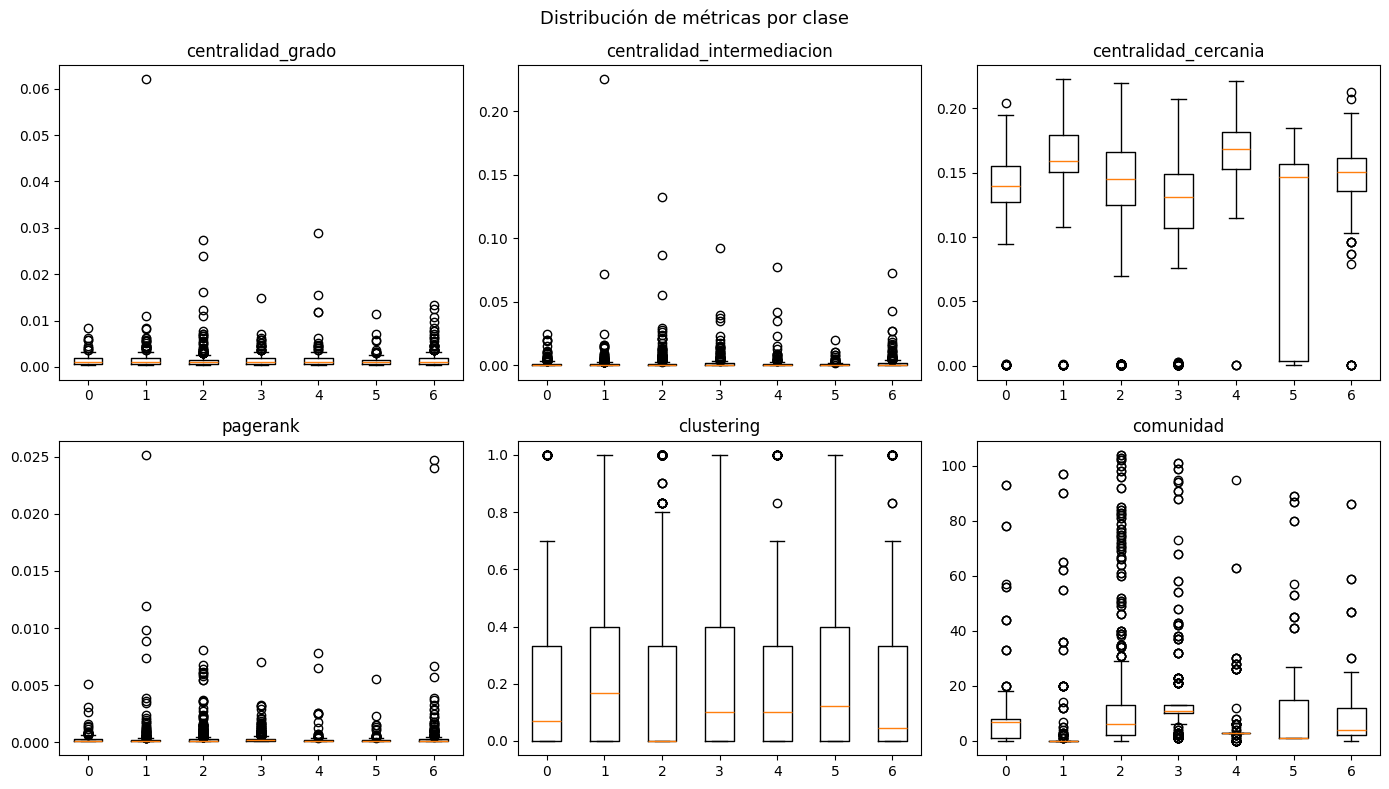

In [23]:
figura, graficas = plt.subplots(2, 3, figsize=(14, 8)) # 6 gráficas distribuidas en 2 filas y 3 columnas
graficas = graficas.flatten()

clases = sorted(metricas_clase['clase'].unique()) # Array ordenado de las clases codificadas : [0, 1, 2, 3, 4, 5, 6]

for grafica, metrica in zip(graficas, metricas_relacionales):
    # Array que almacena los valores de cada clase para la métrica actual
    datos_por_clase = []

    for clase in clases:
        # Selecciona los valores de la columna metrica correspondientes a la clase actual
        valores = metricas_clase.loc[metricas_clase['clase'] == clase, metrica].values
        datos_por_clase.append(valores)

    grafica.boxplot(datos_por_clase, tick_labels=[str(c) for c in clases])
    grafica.set_title(metrica)

plt.suptitle('Distribución de métricas por clase', fontsize=13)
plt.tight_layout()
plt.show()

##### Test de Kruskal-Wallis:

In [24]:
from scipy import stats

In [25]:
print(f'{"Métrica":<29} {"H":>8} {"p-valor":>15} {"Útil?":>9}')
print('-' * 70)

clases = sorted(metricas_clase['clase'].unique())

for metrica in metricas_relacionales:
    datos_por_clase = []

    for clase in clases:
        valores = metricas_clase.loc[metricas_clase['clase'] == clase, metrica].values
        datos_por_clase.append(valores)

    # Aplica el test de Kruskal-Wallis para comprobar si hay diferencias significativas entre clases
    h, p = stats.kruskal(*datos_por_clase)

    # Determina si la métrica es útil según el valor de p (significativo si p < 0.05)
    util = 'Sí' if p < 0.05 else 'No'
    print(f'{metrica:<29} {h:>10.2f} {p:>12.4f} {util:>8}')

Métrica                              H         p-valor     Útil?
----------------------------------------------------------------------
centralidad_grado                  45.38       0.0000       Sí
centralidad_intermediacion         22.16       0.0011       Sí
centralidad_cercania              440.01       0.0000       Sí
pagerank                            6.92       0.3284       No
clustering                         29.83       0.0000       Sí
comunidad                         978.56       0.0000       Sí


## Correlación entre métricas

##### Si dos métricas tienen correlación muy alta (cercana a 1 o -1) están midiendo prácticamente lo mismo y podemos plantear eliminar una.

In [26]:
import seaborn as sns

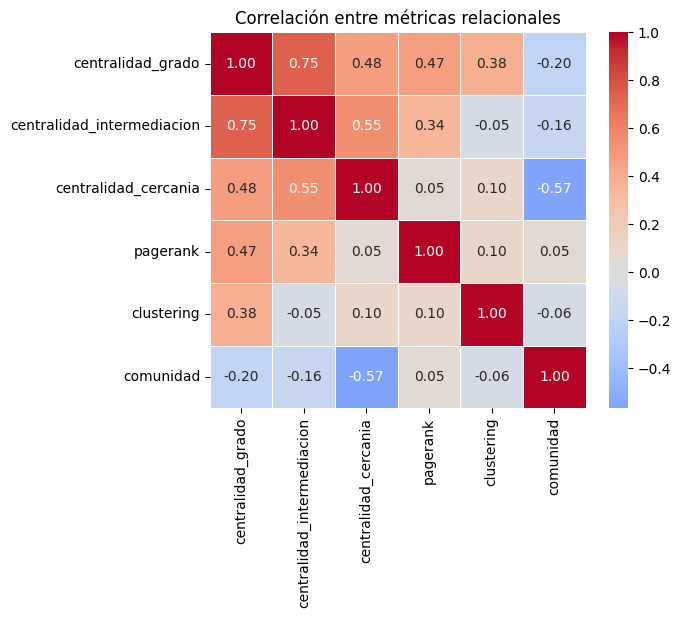

In [27]:
# Correlación de Spearman
correlacion = metricas_clase[metricas_relacionales].corr(method='spearman')

figura, eje = plt.subplots(figsize=(7, 6))

sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=eje)

eje.set_title('Correlación entre métricas relacionales')
plt.tight_layout()
plt.show()